# Sampling figures (linear equations and parenthesized arithmetic)

Publication-oriented plots: **linear** metrics match the previous `test.ipynb` workflow; **parenthesis** metrics are read from `runs/parenthesis/stage1-depth8-100k/grid_search.jsonl` (output of `grid_search_samplers.py`).

In [35]:
"""Global style: NeurIPS/ICML-friendly defaults (vector PDF + 300 dpi raster)."""
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

# Okabe–Ito colorblind-safe palette
SAMPLER_STYLES = {
    "euler": {"color": "#0072B2", "marker": "o", "ls": "-"},
    "staggered": {"color": "#E69F00", "marker": "s", "ls": "-"},
    "split": {"color": "#009E73", "marker": "^", "ls": "-"},
}

METHOD_LABELS = {"euler": "Euler", "staggered": "Staggered", "split": "Split"}
NFE_PER_STEP = {"euler": 1, "staggered": 2, "split": 3}


def configure_matplotlib():
    plt.rcParams.update(
        {
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "font.size": 10.5,
            "axes.labelsize": 11,
            "axes.titlesize": 11.5,
            "axes.titleweight": "medium",
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "legend.fontsize": 9.5,
            "legend.title_fontsize": 10,
            "axes.linewidth": 0.9,
            "grid.linewidth": 0.6,
            "grid.alpha": 0.35,
            "lines.linewidth": 2.0,
            "lines.markersize": 6.5,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Helvetica", "Arial", "sans-serif"],
            "mathtext.fontset": "dejavusans",
        }
    )
    mpl.rcParams["pdf.fonttype"] = 42
    mpl.rcParams["ps.fonttype"] = 42


configure_matplotlib()


def _fraction_ylim(lows: list, highs: list) -> tuple[float, float]:
    """Tight y-limits for [0,1] fractions; pads ~14% of span (min 0.01)."""
    arr_l = np.asarray([x for x in lows if np.isfinite(x)], dtype=float)
    arr_h = np.asarray([x for x in highs if np.isfinite(x)], dtype=float)
    if arr_l.size == 0 or arr_h.size == 0:
        return 0.0, 1.0
    dmin, dmax = float(arr_l.min()), float(arr_h.max())
    span = dmax - dmin
    pad = max(span * 0.15, 0.01)
    ymin = max(0.0, dmin - pad)
    ymax = min(1.0, dmax + pad)
    if ymax - ymin < 0.04:
        mid = 0.5 * (dmin + dmax)
        ymin = max(0.0, mid - 0.02)
        ymax = min(1.0, mid + 0.02)
    if ymax <= ymin:
        ymin, ymax = 0.0, 1.0
    return ymin, ymax


def plot_sampler_curves(
    df: pd.DataFrame,
    *,
    x_col: str,
    x_label: str,
    out_pdf: Path,
    out_png: Path | None = None,
    third_metric: str | None = None,
    third_panel_ylabel: str = "",
):
    """MAE + validity; optional third panel only if ``third_metric`` is set (e.g. ``1-KS`` for L=8)."""
    df = df.sort_values([x_col, "method"]).copy()
    if df.empty:
        print(f"No rows to plot → {out_pdf}")
        return

    panels = [("MAE", "Mean absolute error"), ("valid", "Validity")]
    if third_metric and third_metric in df.columns and third_panel_ylabel:
        panels.append((third_metric, third_panel_ylabel))

    ncols = len(panels)
    fig_w = 4.1 * ncols
    fig, axes = plt.subplots(1, ncols, figsize=(fig_w, 3.35), sharex=False, sharey=False)
    if ncols == 1:
        axes = [axes]

    y_zoom_axes: list[tuple] = []

    def _sampler_panel_title(idx: int, metric: str, y_label: str) -> str:
        letter = f"({chr(ord('a') + idx)}) "
        if metric == "MAE":
            return letter + "Mean absolute error"
        if metric == "valid":
            return letter + "Validity"
        if metric == "1-KS":
            return letter + r"Length ($1-\mathrm{KS}$) vs ground truth"
        return letter + y_label

    for idx, (ax, (metric, y_label)) in enumerate(zip(axes, panels)):
        lows: list = []
        highs: list = []
        for method in sorted(df["method"].unique()):
            sub = df[df["method"] == method].sort_values(x_col)
            sty = SAMPLER_STYLES.get(method, {"color": "#333333", "marker": "o", "ls": "-"})
            yerr = sub[f"{metric}_std"] if f"{metric}_std" in sub.columns else None
            label = METHOD_LABELS.get(method, method)
            y = sub[metric].to_numpy(dtype=float)
            ax.errorbar(
                sub[x_col],
                y,
                yerr=yerr,
                label=label,
                color=sty["color"],
                marker=sty["marker"],
                linestyle=sty["ls"],
                capsize=3.2,
                elinewidth=1.0,
            )
            if metric in ("valid", "accuracy", "1-KS"):
                if yerr is not None:
                    e = np.asarray(yerr.to_numpy(dtype=float), dtype=float)
                    mask = np.isfinite(y) & np.isfinite(e)
                    if mask.any():
                        lows.extend((y[mask] - e[mask]).tolist())
                        highs.extend((y[mask] + e[mask]).tolist())
                    lows.extend(y[np.isfinite(y)].tolist())
                    highs.extend(y[np.isfinite(y)].tolist())
                else:
                    lows.extend(y[np.isfinite(y)].tolist())
                    highs.extend(y[np.isfinite(y)].tolist())
        if metric in ("valid", "accuracy", "1-KS") and not lows:
            y_all = df[metric].to_numpy(dtype=float)
            y_all = y_all[np.isfinite(y_all)]
            if y_all.size:
                lows = y_all.tolist()
                highs = y_all.tolist()
        ax.set_xlabel(x_label)
        if metric == "valid" or metric == "accuracy":
            ax.set_ylabel("Fraction")
            ymin, ymax = _fraction_ylim(lows, highs)
            ax.set_autoscaley_on(False)
            ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
            ax.set_ylim(ymin, ymax)
            y_zoom_axes.append((ax, ymin, ymax))
        elif metric == "1-KS":
            ax.set_ylabel("$1 - \\mathrm{KS}$")
            ymin, ymax = _fraction_ylim(lows, highs)
            ax.set_autoscaley_on(False)
            ax.set_ylim(ymin, ymax)
            y_zoom_axes.append((ax, ymin, ymax))
        else:
            ax.set_ylabel(y_label)
        ax.set_title(_sampler_panel_title(idx, metric, y_label))
        ax.grid(True, axis="y", linestyle="--")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].legend(frameon=False, title="Sampler", loc="best")
    fig.tight_layout(w_pad=1.2)
    for ax, ymin, ymax in y_zoom_axes:
        ax.set_ylim(ymin, ymax)
    fig.savefig(out_pdf)
    if out_png is not None:
        fig.savefig(out_png)
    plt.show()


def load_jsonl(path: Path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


print("Style + helpers ready.")


Style + helpers ready.


## Linear equations (ours vs branching flows vs ground truth)

Per-$L$ histograms and trend curves, as before. Parsing uses `evaluate_equations_parenthesis.parse_equation`, which is valid for these additive linear chains (no `*`).

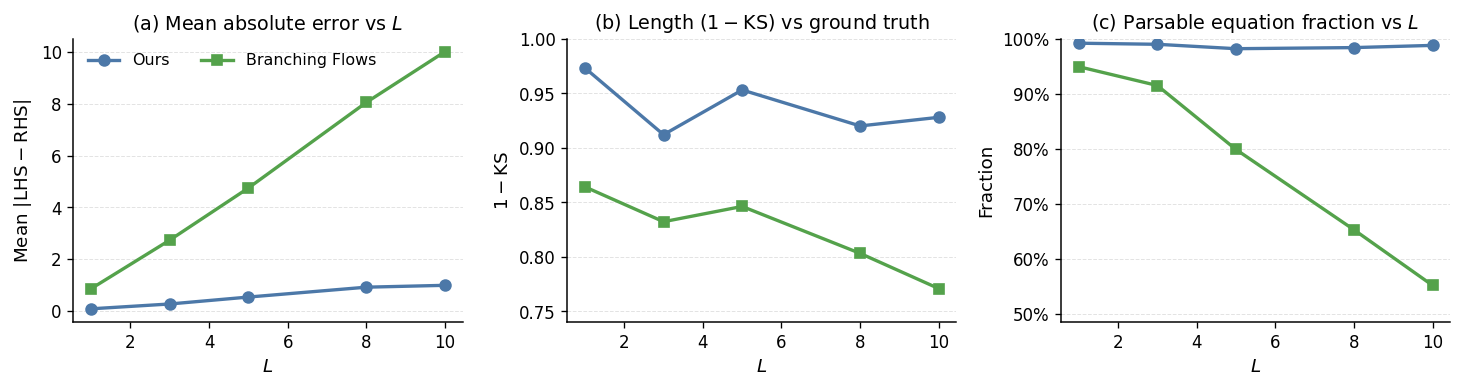


Ours
{'L': 1, 'n_samples': 1000, 'length_ks_vs_gt': 0.026740000000000097, 'mean_abs_error': 0.09073359676427396, 'median_abs_error': 0.06159493140876293, 'valid_abs_error_frac': 0.992}
{'L': 3, 'n_samples': 1000, 'length_ks_vs_gt': 0.08792, 'mean_abs_error': 0.27682569171113874, 'median_abs_error': 0.17770132049918175, 'valid_abs_error_frac': 0.99}
{'L': 5, 'n_samples': 1000, 'length_ks_vs_gt': 0.04691999999999996, 'mean_abs_error': 0.5438474574910624, 'median_abs_error': 0.3535350561141968, 'valid_abs_error_frac': 0.982}
{'L': 8, 'n_samples': 1000, 'length_ks_vs_gt': 0.07992000000000005, 'mean_abs_error': 0.9244405448664954, 'median_abs_error': 0.6384438872337341, 'valid_abs_error_frac': 0.984}
{'L': 10, 'n_samples': 1000, 'length_ks_vs_gt': 0.07199999999999995, 'mean_abs_error': 0.9961313018622442, 'median_abs_error': 0.6591341621242464, 'valid_abs_error_frac': 0.988}

Branching Flows
{'L': 1, 'n_samples': 49410, 'length_ks_vs_gt': 0.13578937462052215, 'mean_abs_error': 0.8679491980

In [36]:
import matplotlib as mpl
from evaluate_equations_parenthesis import (
    count_equation_symbols,
    parse_equation as parse_equation_linear,
)

L_VALUES = [1, 3, 5, 8, 10]

branching_flow_files = [f"branching_flows_samples/equations_l{i}_gen.jsonl" for i in L_VALUES]
our_files = [f"samples_toy-fresh/equations_l{i}/samples.jsonl" for i in L_VALUES]
data_files = [f"data/equations_l{i}.jsonl" for i in L_VALUES]


def extract_l_from_path(path):
    text = str(path)
    m = re.search(r"equations_l(\d+)", text)
    if m:
        return int(m.group(1))
    m = re.search(r"/l(\d+)/", text)
    if m:
        return int(m.group(1))
    raise ValueError(f"Could not infer L from path: {path}")


def equation_length(sample):
    symbols = sample.get("symbols", [])
    if symbols:
        return count_equation_symbols(symbols)
    if "length" in sample:
        return int(sample["length"])
    return len(sample.get("numbers", []))


def equation_abs_error(sample):
    symbols = sample.get("symbols", [])
    positions = sample.get("positions", sample.get("numbers", []))
    if not symbols or not positions:
        return None
    try:
        left_value, right_value = parse_equation_linear(
            symbols,
            positions,
            ignore_trailing_ops=True,
        )
    except Exception:
        return None
    diff = abs(left_value - right_value)
    if diff < 1e-10:
        return 0.0
    return diff


def collect_metrics_by_l(file_paths):
    out = {}
    for path in file_paths:
        l_value = extract_l_from_path(path)
        samples = load_jsonl(Path(path))
        lengths = [equation_length(s) for s in samples]
        abs_errors = []
        for s in samples:
            err = equation_abs_error(s)
            if err is not None:
                abs_errors.append(err)

        out[l_value] = {
            "path": str(Path(path)),
            "n_samples": len(samples),
            "lengths": np.asarray(lengths, dtype=float),
            "abs_errors": np.asarray(abs_errors, dtype=float),
        }
    return out


def ks_2sample_statistic(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if x.size == 0 or y.size == 0:
        return np.nan
    x = np.sort(x)
    y = np.sort(y)
    all_values = np.unique(np.concatenate([x, y]))
    cdf_x = np.searchsorted(x, all_values, side="right") / x.size
    cdf_y = np.searchsorted(y, all_values, side="right") / y.size
    return float(np.max(np.abs(cdf_x - cdf_y)))


def summarize_method(metrics_by_l, gt_metrics_by_l=None):
    rows = []
    for l_value in sorted(metrics_by_l.keys()):
        row = metrics_by_l[l_value]
        lengths = row["lengths"]
        abs_errors = row["abs_errors"]

        length_ks_vs_gt = np.nan
        if gt_metrics_by_l is not None and l_value in gt_metrics_by_l:
            gt_lengths = gt_metrics_by_l[l_value]["lengths"]
            length_ks_vs_gt = ks_2sample_statistic(lengths, gt_lengths)

        rows.append(
            {
                "L": l_value,
                "n_samples": int(row["n_samples"]),
                "length_ks_vs_gt": length_ks_vs_gt,
                "mean_abs_error": float(np.mean(abs_errors)) if abs_errors.size else np.nan,
                "median_abs_error": float(np.median(abs_errors)) if abs_errors.size else np.nan,
                "valid_abs_error_frac": float(abs_errors.size / row["n_samples"]) if row["n_samples"] else np.nan,
            }
        )
    return rows


LINEAR_COLORS = {
    "Ours": "#4C78A8",
    "Branching Flows": "#54A24B",
    "Ground Truth": "#F58518",
}


def plot_comparison_for_l(all_metrics, l_value, bins_abs=20):
    fig, axes = plt.subplots(ncols=2, figsize=(9.2, 3.35))
    line_style = {"Ours": "-", "Branching Flows": "-", "Ground Truth": "-"}

    ax = axes[0]
    abs_methods = ["Ours", "Branching Flows"]
    max_diff_candidates = []
    for method_name in abs_methods:
        errors = all_metrics[method_name][l_value]["abs_errors"]
        if errors.size:
            max_diff_candidates.append(float(np.quantile(errors, 0.99)))
    max_diff = max(max_diff_candidates) if max_diff_candidates else 1.0
    max_diff = max(max_diff, 1e-6)

    for method_name in abs_methods:
        errors = all_metrics[method_name][l_value]["abs_errors"]
        if errors.size == 0:
            continue
        ax.hist(
            errors,
            bins=bins_abs,
            range=(0, max_diff),
            density=True,
            histtype="step",
            color=LINEAR_COLORS[method_name],
            linewidth=2.0,
            linestyle=line_style[method_name],
            label=method_name,
        )
    if not max_diff_candidates:
        ax.text(0.5, 0.5, "No valid equations parsed", ha="center", va="center", transform=ax.transAxes)
    ax.set_xlabel("$|\\mathrm{LHS}-\\mathrm{RHS}|$")
    ax.set_ylabel("Density")
    ax.set_title(f"(a) Mean absolute error ($L={l_value}$)")
    ax.grid(True, axis="y", linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax = axes[1]
    max_len = 1
    for method_name in LINEAR_COLORS:
        lengths = all_metrics[method_name][l_value]["lengths"]
        if lengths.size:
            max_len = max(max_len, int(np.max(lengths)))
    bins = np.arange(1, max_len + 2) - 0.5
    for method_name in LINEAR_COLORS:
        lengths = all_metrics[method_name][l_value]["lengths"]
        if lengths.size == 0:
            continue
        ax.hist(
            lengths,
            bins=bins,
            density=True,
            histtype="step",
            color=LINEAR_COLORS[method_name],
            linewidth=2.0,
            linestyle=line_style[method_name],
            label=method_name,
        )
    bf_len = all_metrics["Branching Flows"][l_value]["lengths"]
    gt_len = all_metrics["Ground Truth"][l_value]["lengths"]
    if bf_len.size and gt_len.size and np.array_equal(bf_len, gt_len):
        ax.text(0.98, 0.95, "BF and GT overlap", ha="right", va="top", fontsize=8.5, transform=ax.transAxes)
    ax.set_xlabel("Sequence length")
    ax.set_title(f"(b) Length distribution ($L={l_value}$)")
    ax.grid(True, axis="y", linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    handles, labels = axes[1].get_legend_handles_labels()
    axes[0].legend(handles, labels, frameon=False, loc="upper left", ncol=3)
    fig.tight_layout(w_pad=1.2)
    fig.savefig(PLOTS_DIR / f"linear_l{l_value}.pdf")
    fig.savefig(PLOTS_DIR / f"linear_l{l_value}.png")
    plt.show()


def plot_trends_vs_l(all_metrics):
    fig, axes = plt.subplots(ncols=3, figsize=(12.3, 3.35))
    styles = {"Ours": (LINEAR_COLORS["Ours"], "o"), "Branching Flows": (LINEAR_COLORS["Branching Flows"], "s")}
    gt_metrics = all_metrics["Ground Truth"]

    ks_vals: list[float] = []
    vf_vals: list[float] = []

    for method_name, (color, marker) in styles.items():
        summary = summarize_method(all_metrics[method_name], gt_metrics_by_l=gt_metrics)
        ls = [r["L"] for r in summary]
        mean_abs = [r["mean_abs_error"] for r in summary]
        length_ks = [r["length_ks_vs_gt"] for r in summary]
        length_one_minus_ks = [1.0 - v if np.isfinite(v) else np.nan for v in length_ks]
        valid_frac = [r["valid_abs_error_frac"] for r in summary]
        axes[0].plot(ls, mean_abs, marker=marker, color=color, label=method_name)
        axes[1].plot(ls, length_one_minus_ks, marker=marker, color=color, label=method_name)
        axes[2].plot(ls, valid_frac, marker=marker, color=color, label=method_name)
        ks_vals.extend(float(x) for x in length_one_minus_ks if np.isfinite(x))
        vf_vals.extend(float(x) for x in valid_frac if np.isfinite(x))

    ylim_ks = _fraction_ylim(ks_vals, ks_vals)
    ylim_vf = _fraction_ylim(vf_vals, vf_vals)

    axes[0].set_title("(a) Mean absolute error vs $L$")
    axes[0].set_xlabel("$L$")
    axes[0].set_ylabel("Mean $|\\mathrm{LHS}-\\mathrm{RHS}|$")

    axes[1].set_title("(b) Length ($1 - \\mathrm{KS}$) vs ground truth")
    axes[1].set_xlabel("$L$")
    axes[1].set_ylabel("$1 - \\mathrm{KS}$")
    axes[1].set_autoscaley_on(False)
    axes[1].set_ylim(*ylim_ks)

    axes[2].set_title("(c) Parsable equation fraction vs $L$")
    axes[2].set_xlabel("$L$")
    axes[2].set_ylabel("Fraction")
    axes[2].set_autoscaley_on(False)
    axes[2].yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
    axes[2].set_ylim(*ylim_vf)

    for ax in axes:
        ax.grid(True, axis="y", linestyle="--")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].legend(handles, labels, frameon=False, loc="upper left", ncol=2)
    fig.tight_layout(w_pad=1.2)
    axes[1].set_ylim(*ylim_ks)
    axes[2].set_ylim(*ylim_vf)
    fig.savefig(PLOTS_DIR / "linear_trends_vs_L.pdf")
    # fig.savefig(PLOTS_DIR / "linear_trends_vs_L.png")
    plt.show()


all_metrics = {
    "Ours": collect_metrics_by_l(our_files),
    "Branching Flows": collect_metrics_by_l(branching_flow_files),
    "Ground Truth": collect_metrics_by_l(data_files),
}

# for l_value in L_VALUES:
#     plot_comparison_for_l(all_metrics, l_value)

plot_trends_vs_l(all_metrics)

gt_metrics = all_metrics["Ground Truth"]
for method_name in ["Ours", "Branching Flows", "Ground Truth"]:
    print(f"\n{method_name}")
    for row in summarize_method(all_metrics[method_name], gt_metrics_by_l=gt_metrics):
        print(row)


## Toy model at $L=8$: MAE, validity, and length $1 - \mathrm{KS}$ vs. GT

Reads `samples_toy/equations_l8_*` with multi-seed aggregation when present. The third panel is $1 - \mathrm{KS}$ between **sequence lengths** (all samples) and ground-truth lengths.


L=8 sampler grid (max_samples=10000): 18 rows


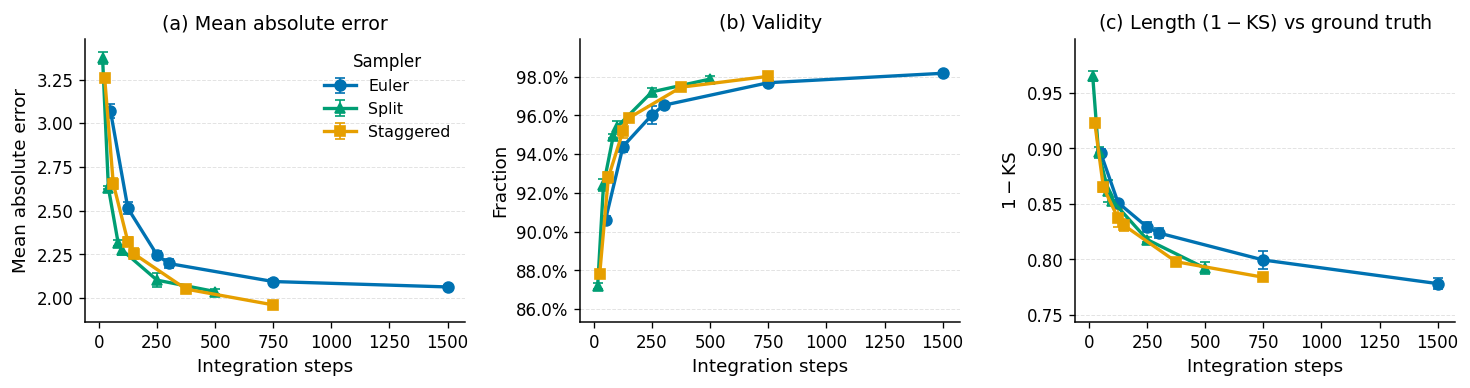

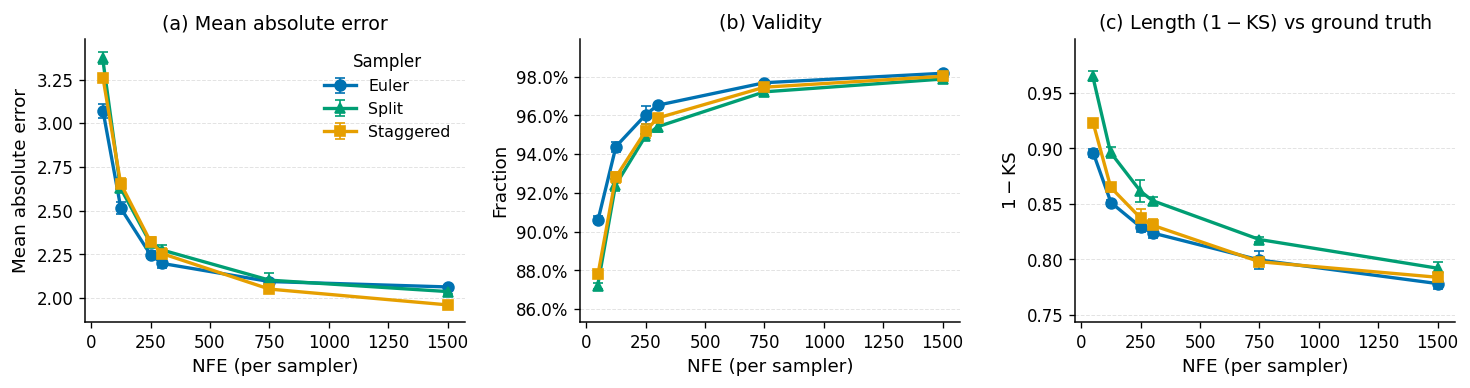

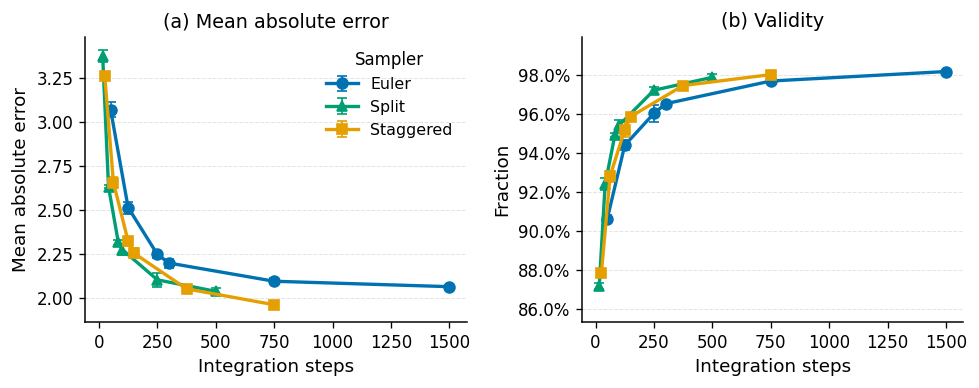

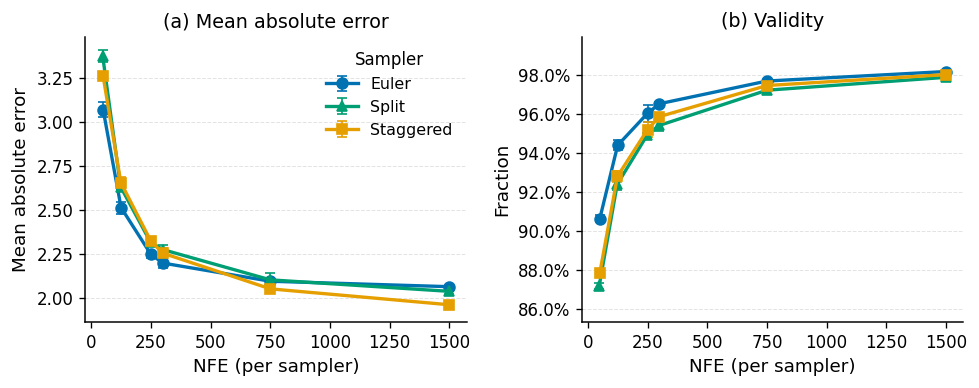

In [37]:
import statistics

from scipy.stats import ks_2samp

SAMPLES_ROOT = Path("samples-full/samples_toy")
L8 = 8
DELTA_ACC = 1.0
MAX_SAMPLES_L8: int | None = 10000


def evaluate_samples_file(
    path: Path,
    gt_lengths: np.ndarray | None = None,
    delta_acc: float = DELTA_ACC,
    max_samples: int | None = None,
):
    samples = load_jsonl(path)
    if max_samples is not None:
        samples = samples[:max_samples]
    total = len(samples)
    errors = [equation_abs_error(s) for s in samples]
    valid_errors = [e for e in errors if e is not None]
    valid_frac = len(valid_errors) / total if total else 0.0
    mae = float(np.mean(valid_errors)) if valid_errors else np.nan
    correct_acc = sum(e < delta_acc for e in valid_errors)
    accuracy = (correct_acc + (total - len(valid_errors)) * 0.0) / total if total else 0.0
    accuracy_on_valid_only = correct_acc / len(valid_errors) if valid_errors else np.nan

    def _length(s):
        if "length" in s:
            return int(s["length"])
        if s.get("symbols"):
            return count_equation_symbols(s["symbols"])
        return len(s.get("positions", s.get("numbers", [])))

    one_minus_ks = np.nan
    if gt_lengths is not None and gt_lengths.size > 0:
        sample_lengths = np.array([_length(s) for s in samples])
        if sample_lengths.size > 0:
            ks_stat, _ = ks_2samp(sample_lengths, gt_lengths)
            one_minus_ks = 1.0 - ks_stat

    return {
        "MAE": mae,
        "valid": valid_frac,
        "accuracy": accuracy,
        "accuracy_valid": accuracy_on_valid_only,
        "1-KS": one_minus_ks,
    }


def collect_results_for_length(length_value: int, max_samples: int | None = None):
    def _sample_length(s):
        if "length" in s:
            return int(s["length"])
        if s.get("symbols"):
            return count_equation_symbols(s["symbols"])
        return len(s.get("positions", s.get("numbers", [])))

    gt_path = Path(f"data/equations_l{length_value}.jsonl")
    gt_lengths = np.array([], dtype=float)
    if gt_path.exists():
        gt_samples = load_jsonl(gt_path)
        gt_lengths = np.array([_sample_length(s) for s in gt_samples])

    method_map = {"euler": ["euler"], "staggered": ["staggered"], "split": ["2ndorder"]}
    out = {m: [] for m in method_map}

    for method_label, method_keys in method_map.items():
        for method_key in method_keys:
            seed_files = sorted(SAMPLES_ROOT.glob(f"equations_l{length_value}_{method_key}_*/seed_*/samples.jsonl"))
            flat_files = sorted(SAMPLES_ROOT.glob(f"equations_l{length_value}_{method_key}_*/samples.jsonl"))
            files = seed_files if seed_files else flat_files

            by_steps: dict[int, list] = {}
            for path in files:
                if "seed_" in str(path):
                    base_name = path.parent.parent.name
                else:
                    base_name = path.parent.name
                m = re.search(r"_(\d+)$", base_name)
                if not m:
                    continue
                steps = int(m.group(1))
                metrics = evaluate_samples_file(path, gt_lengths=gt_lengths, max_samples=max_samples)
                by_steps.setdefault(steps, []).append(metrics)

            for steps, seed_metrics in by_steps.items():
                agg = {"steps": steps}
                for key in ["MAE", "valid", "accuracy", "1-KS"]:
                    vals = [m[key] for m in seed_metrics]
                    agg[key] = statistics.fmean(vals)
                    agg[f"{key}_std"] = statistics.stdev(vals) if len(vals) > 1 else 0.0
                out[method_label].append(agg)

        uniq = {row["steps"]: row for row in out[method_label]}
        out[method_label] = sorted(uniq.values(), key=lambda x: x["steps"])

    out = {k: v for k, v in out.items() if v}
    if not out:
        return out

    def nfe_for(method_label: str, steps: int) -> int:
        return steps * NFE_PER_STEP.get(method_label, 1)

    def nfe_bin(nfe: int) -> int:
        return round(nfe / 25) * 25

    nfe_sets = []
    for method_label, entries in out.items():
        nfe_sets.append({nfe_bin(nfe_for(method_label, r["steps"])) for r in entries})
    shared = set.intersection(*nfe_sets)

    for method_label in out:
        out[method_label] = sorted(
            [r for r in out[method_label] if nfe_bin(nfe_for(method_label, r["steps"])) in shared],
            key=lambda x: x["steps"],
            reverse=True,
        )
    return out


def sampler_dict_to_df(results_dict):
    rows = []
    for method, entries in results_dict.items():
        nfe_ps = NFE_PER_STEP.get(method, 1)
        for e in entries:
            rows.append({"method": method, **e, "nfe": e["steps"] * nfe_ps})
    return pd.DataFrame(rows)


results_l8 = collect_results_for_length(L8, max_samples=MAX_SAMPLES_L8)
df_l8 = sampler_dict_to_df(results_l8)
print(f"L={L8} sampler grid (max_samples={MAX_SAMPLES_L8}):", len(df_l8), "rows")

if not df_l8.empty:
    plot_sampler_curves(
        df_l8,
        x_col="steps",
        x_label="Integration steps",
        out_pdf=PLOTS_DIR / "toy_l8_samplers_steps.pdf",
        # out_png=PLOTS_DIR / "toy_l8_samplers_steps.png",
        third_metric="1-KS",
        third_panel_ylabel="Length vs. GT ($1 - \\mathrm{KS}$)",
    )
    plot_sampler_curves(
        df_l8.sort_values("nfe"),
        x_col="nfe",
        x_label="NFE (per sampler)",
        out_pdf=PLOTS_DIR / "toy_l8_samplers_nfe.pdf",
        # out_png=PLOTS_DIR / "toy_l8_samplers_nfe.png",
        third_metric="1-KS",
        third_panel_ylabel="Length vs. GT ($1 - \\mathrm{KS}$)",
    )
    plot_sampler_curves(
        df_l8,
        x_col="steps",
        x_label="Integration steps",
        out_pdf=PLOTS_DIR / "toy_l8_samplers_steps_2p.pdf",
        # out_png=PLOTS_DIR / "toy_l8_samplers_steps_2p.png",
    )
    plot_sampler_curves(
        df_l8.sort_values("nfe"),
        x_col="nfe",
        x_label="NFE (per sampler)",
        out_pdf=PLOTS_DIR / "toy_l8_samplers_nfe_2p.pdf",
        # out_png=PLOTS_DIR / "toy_l8_samplers_nfe_2p.png",
    )
else:
    print("No samples under samples_toy/ — skip L=8 sampler plots.")


## Parenthesis: grid search (`grid_search.jsonl`)

Same line/errorbar aesthetic as the $L=8$ toy panel. Adjust `GRID_SEARCH_JSONL` if your run directory differs.

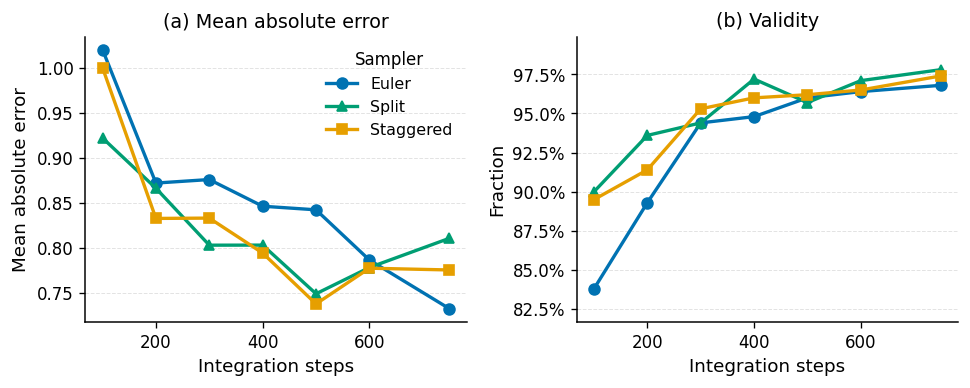

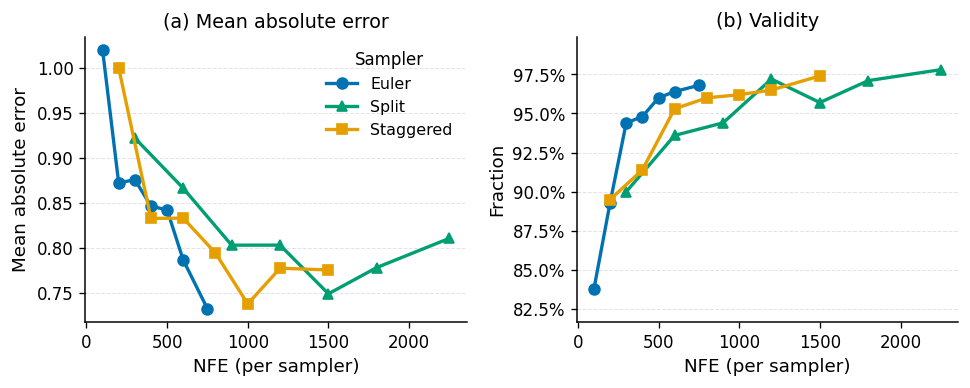

In [38]:
GRID_SEARCH_JSONL = Path("runs/parenthesis/stage1-depth8-100k/grid_search.jsonl")


def load_parenthesis_grid(path: Path) -> pd.DataFrame:
    rows = []
    if not path.exists():
        print(f"Missing {path} — generate with grid_search_samplers.py")
        return pd.DataFrame()
    for r in load_jsonl(path):
        n = int(r["eval_samples"])
        rows.append(
            {
                "method": r["sampler"],
                "steps": int(r["steps"]),
                "nfe": int(r["steps"]) * NFE_PER_STEP[r["sampler"]],
                "MAE": float(r["mean_abs_error"]),
                "valid": float(r["valid"]) / n,
                # Match toy panel: fraction of all samples that parse and meet threshold |Δ| < 0.5
                "accuracy": float(r["correct"]) / n,
                "accuracy_cond_valid": float(r["accuracy"]),
            }
        )
    return pd.DataFrame(rows)


df_paren = load_parenthesis_grid(GRID_SEARCH_JSONL)

if not df_paren.empty:
    plot_sampler_curves(
        df_paren,
        x_col="steps",
        x_label="Integration steps",
        out_pdf=PLOTS_DIR / "parenthesis_grid_samplers_steps.pdf",
        # out_png=PLOTS_DIR / "parenthesis_grid_samplers_steps.png",
    )
    plot_sampler_curves(
        df_paren.sort_values("nfe"),
        x_col="nfe",
        x_label="NFE (per sampler)",
        out_pdf=PLOTS_DIR / "parenthesis_grid_samplers_nfe.pdf",
        # out_png=PLOTS_DIR / "parenthesis_grid_samplers_nfe.png",
    )
    df_paren.sort_values(["method", "steps"]).reset_index(drop=True)
else:
    print("No parenthesis grid to plot.")
